# Data preparation and cleaning

## 1) Load all data of accepted loans

[Source](https://www.kaggle.com/datasets/wordsforthewise/lending-club/data)
[Feature explanation](https://github.com/bacover/Capstone-LendingClub/blob/main/LCDataDictionary.xlsx)

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

data = pd.read_csv("data/accepted_2007_to_2018Q4.csv")

## 2) Set columns for prediction
Only finished statuses of loans. Fully paid - 0, Not paid - 1.

In [2]:
data["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [3]:
valid_statuses = ['Fully Paid', 'Charged Off', 'Default']
data = data[data['loan_status'].isin(valid_statuses)].copy()
data['target'] = np.where(data['loan_status'] == 'Fully Paid', 0, 1)
data = data.drop(columns=['loan_status'])

Calculation of annual ROI

In [4]:
data = data.dropna(subset=['last_pymnt_d'])

In [5]:
data['issue_d'] = pd.to_datetime(data['issue_d'], format='%b-%Y')
data['last_pymnt_d'] = pd.to_datetime(data['last_pymnt_d'], format='%b-%Y')

data['actual_duration_months'] = (data['last_pymnt_d'].dt.year - data['issue_d'].dt.year) * 12 + \
                                 (data['last_pymnt_d'].dt.month - data['issue_d'].dt.month)

data['actual_duration_months'] = data['actual_duration_months'].replace(0, 1)

actual_years = data['actual_duration_months'] / 12

data['target_annual_roi'] = (data['total_pymnt'] / data['loan_amnt']) ** (1 / actual_years) - 1


In [6]:
data["target_annual_roi"].isna().sum()

0

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1343037 entries, 0 to 2260697
Columns: 153 entries, id to target_annual_roi
dtypes: datetime64[ns](2), float64(114), int32(1), int64(1), object(35)
memory usage: 1.5+ GB


## 3) Chronological train tets split

In [8]:
data = data.set_index('id')

data["issue_d"] = pd.to_datetime(data["issue_d"], format="%b-%Y", errors="coerce")

data = data.dropna(subset=["issue_d"]).sort_values("issue_d")

split_idx = int(len(data) * 0.8)
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

print(len(train_df), len(test_df))
print(train_df["issue_d"].min(), train_df["issue_d"].max())
print(test_df["issue_d"].min(), test_df["issue_d"].max())

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, shuffle=False)


1074429 268608
2007-06-01 00:00:00 2016-10-01 00:00:00
2016-10-01 00:00:00 2018-12-01 00:00:00


## 4) Find columns to drop

In [9]:
train_df[(train_df["loan_amnt"] != train_df["funded_amnt"]) & (train_df["loan_amnt"] > 0) & (train_df["funded_amnt"] > 0)]

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target,actual_duration_months,target_annual_roi
id,,,,,,,,,,,,,,,,,,,,,
140036,NaN,4000.0,1000.0,550.000000,36 months,9.96,32.25,B,B5,Schering-Plough Corp.,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,27,-0.492187
139980,NaN,12000.0,5000.0,1399.996684,36 months,10.91,163.49,C,C3,Staples,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,29,-0.314330
141774,NaN,20000.0,4800.0,1949.999594,36 months,13.12,162.01,D,D5,Legal Services of New Jersey,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,10,-0.951535
137042,NaN,25000.0,5650.0,725.000000,36 months,14.38,194.15,E,E4,MSIP,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,36,-0.346120
180712,NaN,22550.0,12000.0,2225.000000,36 months,15.96,421.65,F,F4,Polygon Company,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,36,-0.123602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5335336,NaN,27500.0,27475.0,27475.000000,60 months,23.83,787.70,F,F5,Internal Revenue Service,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,21,0.203396
5345475,NaN,25000.0,24975.0,24975.000000,60 months,23.83,716.02,F,F5,U.S Army Materiel Command,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,3,0.253545
5649239,NaN,33425.0,33325.0,33275.000000,60 months,19.72,877.73,D,D5,Dunbar Armored,...,N,NaN,NaN,NaN,NaN,NaN,NaN,0,60,0.095185


In [10]:
sum((train_df['grade'] == train_df['sub_grade'].str[0]))/len(train_df)

1.0

<Axes: >

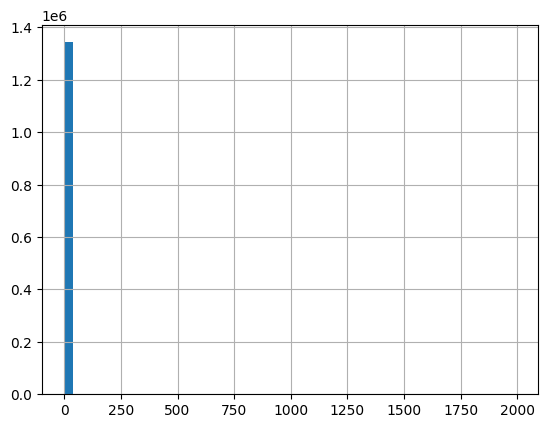

In [11]:
data[data["out_prncp"] < 2000]["out_prncp"].hist(bins=50)

In [12]:
data[data["next_pymnt_d"] == "Apr-2019"]

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target,actual_duration_months,target_annual_roi
id,,,,,,,,,,,,,,,,,,,,,
24776849,NaN,12000.0,12000.0,12000.0,60 months,12.49,269.92,B,B5,Supervisor,...,Y,Feb-2019,ACTIVE,Feb-2019,1190.0,44.99,3.0,1,55,0.033269
66510505,NaN,35000.0,35000.0,35000.0,60 months,20.99,946.68,E,E5,Support Officer,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,39,-0.040461
73450282,NaN,10950.0,10950.0,10950.0,36 months,18.25,397.25,D,D3,NaN,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,36,0.051235
77396993,NaN,12000.0,12000.0,12000.0,36 months,11.99,398.52,C,C1,Associate Director - Market Risk,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,35,0.010415
79074327,NaN,4000.0,4000.0,4000.0,36 months,11.47,131.85,B,B5,Receptionist/Administrative Assistant,...,Y,Mar-2019,ACTIVE,Mar-2019,463.0,50.08,1.0,1,34,0.026086
78119683,NaN,16625.0,16625.0,16625.0,60 months,24.99,487.87,E,E5,Packaging mechanic,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,34,-0.031141
91643221,NaN,8400.0,8400.0,8400.0,36 months,14.99,291.15,C,C4,Social Worker,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,24,-0.086570
92272002,NaN,20025.0,20025.0,20025.0,36 months,17.99,723.86,D,D2,NaN,...,N,NaN,NaN,NaN,NaN,NaN,NaN,1,28,-0.051172
94155408,NaN,5500.0,5500.0,5500.0,36 months,7.49,171.06,A,A4,corrections officer,...,Y,Feb-2019,ACTIVE,Feb-2019,983.0,45.00,4.0,1,28,-0.111107


Also used Data Wrangler VSCode Extension

In [ ]:
cols_to_drop = [
    "member_id", # 100% NA
    "funded_amnt", # 99,9% same as loan_amnt
    "funded_amnt_inv", # Not known at the time of application
    "grade", # 100% values correspond to letter in sub_grade
    "emp_title", # 31% different values - text values - would require text mining
    "pymnt_plan", # 100% values "n"
    "url", # 100% unique not useful values
    "desc", # Text mining needed
    "title", # Text mining needed
    "zip_code", # 939 categories and corresponding to addr_state
    "out_prncp", # Info about target
    "out_prncp_inv", # Info about target
    "total_pymnt", # Info about target
    "total_pymnt_inv", # Info about target
    "total_rec_prncp", # Info about target
    "total_rec_int", # Info about target
    "total_rec_late_fee", # Info about target
    "recoveries", # Info about target
    "collection_recovery_fee", # Info about target
    "last_pymnt_d", # Info about target
    "last_pymnt_amnt", # Info about target
    "next_pymnt_d", # Info about target
    "last_credit_pull_d", # Info about target
    "last_fico_range_high", # Info about target
    "last_fico_range_low", # Info about target
    "policy_code", # All values are 1
    "revol_bal_joint", # 100% NA in train set
    "sec_app_fico_range_low", # 100% NA in train set
    "sec_app_fico_range_high", # 100% NA in train set
    "sec_app_earliest_cr_line", # 100% NA in train set
    "sec_app_inq_last_6mths", # 100% NA in train set
    "sec_app_mort_acc", # 100% NA in train set
    "sec_app_open_acc", # 100% NA in train set
    "sec_app_revol_util", # 100% NA in train set
    "sec_app_open_act_il", # 100% NA in train set
    "sec_app_num_rev_accts", # 100% NA in train set
    "sec_app_chargeoff_within_12_mths", # 100% NA in train set
    "sec_app_collections_12_mths_ex_med", # 100% NA in train set
    "sec_app_mths_since_last_major_derog", # 100% NA in train set
    "hardship_flag", # Info about target and 100% values "N"
    "hardship_type", # Info about target
    "hardship_reason", # Info about target
    "hardship_status", # Info about target
    "deferral_term", # Info about target
    "hardship_amount", # Info about target
    "hardship_start_date", # Info about target
    "hardship_end_date", # Info about target
    "payment_plan_start_date", # Info about target
    "hardship_length", # Info about target
    "hardship_dpd", # Info about target
    "hardship_loan_status", # Info about target
    "orig_projected_additional_accrued_interest", # Info about target
    "hardship_payoff_balance_amount", # Info about target
    "hardship_last_payment_amount", # Info about target
    "debt_settlement_flag", # Info about target
    "debt_settlement_flag_date", # Info about target
    "settlement_status", # Info about target
    "settlement_date", # Info about target
    "settlement_amount", # Info about target
    "settlement_percentage", # Info about target
    "settlement_term", # Info about target
    "actual_duration_months", # Not known at the time of application
]

In [14]:
cols_to_unordered_cat = [
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "initial_list_status",
    "application_type",
    "disbursement_method"
]

In [15]:
cols_to_ordered_cat = [
    "term",
    "sub_grade",
    "emp_length",
]

In [16]:
cols_to_engineer = [
    "issue_d", # Month and year, keep as datetime
    "earliest_cr_line", # Month and year, difference with issue_d and keep as datetime
    "fico_range_low", "fico_range_high", # Mean and drop
]

In [ ]:
# Just written but not used for tree boosting models

cols_to_fill_na_with_extreme = [
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_last_major_derog"
]

In [ ]:
# Just written but not used for tree boosting models

cols_with_outliers = [
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "tot_coll_amt"
    "tot_cur_bal",
    "open_il_24m",
    "mths_since_rcnt_il",
    "total_rev_hi_lim",
    "avg_cur_bal",
    "bc_open_to_buy",
    "bc_util",
    "delinq_amnt",
    "tot_hi_cred_lim",
    "total_bc_limit"
]

In [19]:
cols_to_combine_joint = [
    "annual_inc_joint",
    "dti_joint",
    "verification_status_joint"
]

In [ ]:
# Just written but not used for tree boosting models

cols_with_NA_at_start = [
    "open_acc_6m",
    "open_act_il",
    "open_il_12m",
    "open_il_24m",
    "mths_since_rcnt_il",
    "total_bal_il",
    "il_util",
    "open_rv_12m",
    "open_rv_24m",
    "max_bal_bc",
    "all_util",
    "inq_fi",
    "total_cu_tl",
    "inq_last_12m",
    "mths_since_recent_bc_dlq"
]

## 5) Drop columns and adjustions

In [21]:
data = data.drop(columns=cols_to_drop)

Average fico - fico_range_low and fico_range_high has allways difference of 4 and in some cases 5

In [22]:
data["fico_avg"] = (data["fico_range_low"] + data["fico_range_high"])/2

data[["fico_avg", "fico_range_low", "fico_range_high"]]

,fico_avg,fico_range_low,fico_range_high
id,,,
87023,662.0,660.0,664.0
112323,682.0,680.0,684.0
99009,792.0,790.0,794.0
112245,772.0,770.0,774.0
109355,662.0,660.0,664.0
...,...,...,...
144587705,687.0,685.0,689.0
144359153,732.0,730.0,734.0
144793741,702.0,700.0,704.0


In [23]:
data = data.drop(columns = ["fico_range_low", "fico_range_high"])

Datetime columns feature engineering

In [24]:
data["earliest_cr_line"] = pd.to_datetime(data["earliest_cr_line"], format="%b-%Y", errors="coerce")

data["issue_d_year"] = data["issue_d"].dt.year
data["issue_d_month"] = data["issue_d"].dt.month

data["earliest_cr_line_year"] = data["earliest_cr_line"].dt.year
data["earliest_cr_line_month"] = data["earliest_cr_line"].dt.month

data["credit_history_length_mths"] = (data["issue_d_year"] - data["earliest_cr_line_year"]) * 12 + (data["issue_d_month"] - data["earliest_cr_line_month"])

data["credit_history_length_mths"] = data["credit_history_length_mths"].clip(lower=0)

data["issue_d"] = pd.to_datetime(data["issue_d"], format="%b-%Y", errors="coerce")

data = data.dropna(subset=["issue_d"]).sort_values("issue_d")

for col in ["issue_d", "earliest_cr_line"]:
    data[col + "_numeric"] = (data[col] - pd.Timestamp("1970-01-01")).dt.days

    cyclical_cols = ['issue_d_month', 'earliest_cr_line_month']

for col in cyclical_cols:
    if col in data.columns:
        data[f'{col}_sin'] = np.sin(2 * np.pi * data[col] / 12.0)
        data[f'{col}_cos'] = np.cos(2 * np.pi * data[col] / 12.0)

Joint applications engineering

In [25]:
data["annual_inc"] = np.where(data["application_type"] == "Joint App", data["annual_inc_joint"], data["annual_inc"])
data["dti"] = np.where(data["application_type"] == "Joint App", data["dti_joint"], data["dti"])
data["verification_status"] = np.where(data["application_type"] == "Joint App", data["verification_status_joint"], data["verification_status"])

data = data.drop(columns=["annual_inc_joint", "dti_joint", "verification_status_joint"])

Convertion to category type

In [26]:
data[cols_to_unordered_cat] = data[cols_to_unordered_cat].astype("category")
data[cols_to_ordered_cat] = data[cols_to_ordered_cat].astype("category")

In [27]:
data.select_dtypes(include=['object']).columns

Index([], dtype='object')

Update train and test sets after adjustions on whole data

In [28]:
split_idx = int(len(data) * 0.8)
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

print(len(train_df), len(test_df))
print(train_df["issue_d"].min(), train_df["issue_d"].max())
print(test_df["issue_d"].min(), test_df["issue_d"].max())

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, shuffle=False)

1074429 268608
2007-06-01 00:00:00 2016-10-01 00:00:00
2016-10-01 00:00:00 2018-12-01 00:00:00


## 6) Work with categorical features

In [29]:
all_cat_cols = train_df.select_dtypes(include=['object', 'category']).columns

cat_counts = train_df[all_cat_cols].nunique().sort_values(ascending=False)

print("Unique values in categorical columns:")
print(cat_counts)

Unique values in categorical columns:
addr_state             51
sub_grade              35
purpose                14
emp_length             11
home_ownership          6
verification_status     3
term                    2
initial_list_status     2
application_type        2
disbursement_method     2
dtype: int64


In [30]:
train_df["disbursement_method"].value_counts(normalize=True, dropna=False) * 100

disbursement_method
Cash         99.800918
DirectPay     0.199082
Name: proportion, dtype: float64

In [31]:
train_df["application_type"].value_counts(normalize=True, dropna=False) * 100

application_type
Individual    99.636272
Joint App      0.363728
Name: proportion, dtype: float64

In [32]:
train_df["initial_list_status"].value_counts(normalize=True, dropna=False) * 100

initial_list_status
w    53.887414
f    46.112586
Name: proportion, dtype: float64

In [33]:
train_df["term"].value_counts(normalize=True, dropna=False) * 100

term
36 months    75.881515
60 months    24.118485
Name: proportion, dtype: float64

In [34]:
train_df["verification_status"].value_counts(normalize=True, dropna=False) * 100

verification_status
Source Verified    38.342878
Verified           32.016448
Not Verified       29.640674
Name: proportion, dtype: float64

In [35]:
train_df["home_ownership"].value_counts(normalize=True, dropna=False) * 100

home_ownership
MORTGAGE    49.322291
RENT        40.260175
OWN         10.399105
OTHER        0.013402
NONE         0.004188
ANY          0.000838
Name: proportion, dtype: float64

In [36]:
train_df["emp_length"].value_counts(normalize=True, dropna=False) * 100


emp_length
10+ years    32.796025
2 years       9.006738
3 years       7.967302
< 1 year      7.880000
1 year        6.566465
5 years       6.282314
4 years       5.952743
NaN           5.433025
8 years       4.846109
6 years       4.728372
7 years       4.647771
9 years       3.893138
Name: proportion, dtype: float64

In [37]:
train_df["purpose"].value_counts(normalize=True, dropna=False) * 100

purpose
debt_consolidation    58.623045
credit_card           22.625972
home_improvement       6.154711
other                  5.260003
major_purchase         2.067238
small_business         1.166201
car                    1.046696
medical                1.038970
moving                 0.664911
vacation               0.601343
house                  0.441909
wedding                0.212206
renewable_energy       0.066733
educational            0.030062
Name: proportion, dtype: float64

In [38]:
train_df["sub_grade"].value_counts(normalize=True, dropna=False) * 100

sub_grade
B4    6.371012
B3    6.348488
C1    6.216232
B5    5.953953
C2    5.870374
B2    5.655097
C3    5.516791
C4    5.372342
B1    5.188989
A5    4.949327
C5    4.653635
A4    4.014970
D1    3.884389
A1    3.281371
D2    3.238185
D3    2.785293
A3    2.752439
A2    2.717350
D4    2.677701
D5    2.221459
E1    1.892075
E2    1.690852
E3    1.436763
E4    1.200359
E5    0.996715
F1    0.775668
F2    0.577888
F3    0.478207
F4    0.376386
F5    0.294203
G1    0.205505
G2    0.155711
G3    0.111408
G4    0.076692
G5    0.062173
Name: proportion, dtype: float64

In [39]:
train_df["addr_state"].value_counts(normalize=True, dropna=False) * 100

addr_state
CA    14.675144
NY     8.275652
TX     8.146746
FL     7.009770
IL     3.921525
NJ     3.684003
PA     3.417164
OH     3.307524
GA     3.251122
VA     2.871479
NC     2.791995
MI     2.601103
AZ     2.373354
MD     2.317975
MA     2.303084
WA     2.166825
CO     2.147652
MN     1.780574
MO     1.585493
IN     1.578420
TN     1.487209
CT     1.479949
NV     1.448676
WI     1.308044
AL     1.241776
OR     1.220183
SC     1.183699
LA     1.169086
KY     0.950831
OK     0.914253
KS     0.858037
AR     0.751655
UT     0.721220
NM     0.554899
HI     0.506222
NH     0.475508
MS     0.462664
RI     0.435208
WV     0.420595
MT     0.285919
DE     0.278380
DC     0.269352
AK     0.248039
WY     0.226632
NE     0.210158
SD     0.206994
VT     0.197686
ME     0.113921
ND     0.097819
ID     0.068129
IA     0.000652
Name: proportion, dtype: float64

Combine categories for home_ownership

In [40]:
home_cats_to_other = ["NONE", "ANY"]

data["home_ownership"] = data["home_ownership"].astype(object).replace(home_cats_to_other, "OTHER").astype("category")

print(data["home_ownership"].unique())

['OWN', 'MORTGAGE', 'RENT', 'OTHER']
Categories (4, object): ['MORTGAGE', 'OTHER', 'OWN', 'RENT']


Convert ordered categories to int

In [41]:
data["term_months"] = data["term"].astype(str).str.extract(r'(\d+)').astype("Int64")

data = data.drop(columns=["term"])

emp_length_order = ["< 1 year", "1 year", "2 years", "3 years", "4 years", 
                                        "5 years", "6 years", "7 years", "8 years", "9 years", "10+ years"]

sub_grade_order = sorted(data["sub_grade"].dropna().astype(str).unique()) 


sub_grade_mapping = {category: index for index, category in enumerate(sub_grade_order)}
emp_length_mapping = {category: index for index, category in enumerate(emp_length_order)}

    
data["sub_grade"] = data["sub_grade"].astype(str).map(sub_grade_mapping).astype("Int64")
data["emp_length"] = data["emp_length"].astype(str).map(emp_length_mapping).astype("Int64")

print("Unique values in 'term':", data["term_months"].unique())
display(data[["term_months", "sub_grade", "emp_length"]].head())

Unique values in 'term': <IntegerArray>
[36, 60]
Length: 2, dtype: Int64


,term_months,sub_grade,emp_length
id,,,
87023,36,21,0
92552,36,9,4
96350,36,13,1
94838,36,10,2
93277,36,5,0


Unification of numbers data type

In [42]:
old_int_cols = data.select_dtypes(include=['int32', 'int64']).columns

data[old_int_cols] = data[old_int_cols].astype("Int64")

float_cols = data.select_dtypes(include=['float32']).columns
data[float_cols] = data[float_cols].astype("float64")

print(data.dtypes.astype(str).value_counts())

float64           77
Int64             11
category           7
datetime64[ns]     2
Name: count, dtype: int64


Final train test split after all work

In [43]:
split_idx = int(len(data) * 0.8)
train_df = data.iloc[:split_idx]
test_df = data.iloc[split_idx:]

print(len(train_df), len(test_df))
print(train_df["issue_d"].min(), train_df["issue_d"].max())
print(test_df["issue_d"].min(), test_df["issue_d"].max())

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.2, shuffle=False)

1074429 268608
2007-06-01 00:00:00 2016-10-01 00:00:00
2016-10-01 00:00:00 2018-12-01 00:00:00


In [47]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1074429 entries, 87023 to 91487040
Data columns (total 97 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   loan_amnt                       1074429 non-null  float64       
 1   int_rate                        1074429 non-null  float64       
 2   installment                     1074429 non-null  float64       
 3   sub_grade                       1074429 non-null  Int64         
 4   emp_length                      1016055 non-null  Int64         
 5   home_ownership                  1074429 non-null  category      
 6   annual_inc                      1074429 non-null  float64       
 7   verification_status             1074429 non-null  category      
 8   issue_d                         1074429 non-null  datetime64[ns]
 9   purpose                         1074429 non-null  category      
 10  addr_state                      1074429 no

## 7) Save in parquet files for column types saving 

In [45]:
train_df.index = train_df.index.astype(str)
test_df.index = test_df.index.astype(str)

train_df.to_parquet("data/train_data.parquet")
test_df.to_parquet("data/test_data.parquet")

train_df.index = pd.to_numeric(train_df.index, errors="coerce")
test_df.index = pd.to_numeric(test_df.index, errors="coerce")